# SuperbCommand – Multi-Asset CTA Strategy
## Notebook 08 — SuperbCommand + Dual-Trend Composite Research

**Purpose:** test whether SuperbCommand adds useful information when combined with the strongest simple benchmark identified in Notebooks 06–07:

\[
\boxed{\text{13/52 Dual Trend + Hierarchical Inverse Volatility}}
\]

Notebook 08 is a **structural-combination experiment**, not a fine-tuning exercise.

### Fixed ingredients

The SuperbCommand leg is fixed as:

- `PT_REDUCE_25`
- long/cash
- hierarchical inverse volatility

The conventional trend leg is fixed as:

- 13-week + 52-week dual-horizon trend
- long/cash
- hierarchical inverse volatility

### Pre-specified composite weights

Only five coarse allocations are tested:

\[
100/0,\quad75/25,\quad50/50,\quad25/75,\quad0/100
\]

where the first number is the weight on SuperbCommand and the second is the weight on Dual Trend.

No continuous blend optimisation is performed.

### Main research question

> **Does combining SuperbCommand's regime-management architecture with conventional medium/long-horizon trend improve risk-adjusted performance, drawdown behaviour, or stress-period robustness?**

### Holdout discipline

The research sample remains locked at:

**31 December 2025**

The entire 2026 period remains untouched.


In [1]:
# ============================================================
# 8.1 — IMPORTS, DRIVE & PROJECT CONFIGURATION
# ============================================================
from __future__ import annotations

import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

PROJECT_ROOT = (
    Path("/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy")
    if IN_COLAB
    else Path.cwd() / "Multi-Asset CTA Strategy"
)

CONFIG_PATH = PROJECT_ROOT / "config" / "project_config.json"
if not CONFIG_PATH.exists():
    raise FileNotFoundError("Run Notebook 00 first.")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CFG = json.load(f)

PATHS = {k: Path(v) for k, v in CFG["paths"].items()}

RESEARCH_END = pd.Timestamp(CFG["research_dates"]["research_end"])
HOLDOUT_START = pd.Timestamp(CFG["research_dates"]["holdout_start"])

if CFG["research_dates"]["unlock_holdout"]:
    raise RuntimeError("Notebook 08 cannot run with the 2026 holdout unlocked.")

SC_RETURNS_PATH = PATHS["data_processed"] / "05_portfolio_return_panel.parquet"
BASELINE_RETURNS_PATH = PATHS["data_processed"] / "06_baseline_return_panel.parquet"

for p in [SC_RETURNS_PATH, BASELINE_RETURNS_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Required upstream file not found: {p}")

print("Project:", PROJECT_ROOT)
print("Research cutoff:", RESEARCH_END.date())
print("2026 holdout: LOCKED")


Mounted at /content/drive
Project: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy
Research cutoff: 2025-12-31
2026 holdout: LOCKED


In [2]:
# ============================================================
# 8.2 — LOAD FIXED STRATEGY LEGS
# ============================================================
sc_panel = pd.read_parquet(SC_RETURNS_PATH)
baseline_panel = pd.read_parquet(BASELINE_RETURNS_PATH)

if sc_panel.index.max() >= HOLDOUT_START:
    raise RuntimeError("Holdout contamination in SuperbCommand returns.")

if baseline_panel.index.max() >= HOLDOUT_START:
    raise RuntimeError("Holdout contamination in baseline returns.")

SC_KEY = ("PT_REDUCE_25", "hier_inverse_vol")
DT_KEY = ("DUAL_TREND_13_52", "hier_inverse_vol")

if SC_KEY not in sc_panel.columns:
    raise KeyError(f"Missing SuperbCommand series: {SC_KEY}")

if DT_KEY not in baseline_panel.columns:
    raise KeyError(f"Missing Dual Trend series: {DT_KEY}")

sc = sc_panel[SC_KEY].rename("SuperbCommand")
dt = baseline_panel[DT_KEY].rename("DualTrend")

legs = pd.concat([sc, dt], axis=1).dropna(how="any")
legs = legs.loc[:RESEARCH_END]

print("Common sample:", legs.index.min().date(), "→", legs.index.max().date())
print("Weeks:", len(legs))
display(legs.tail())


Common sample: 2006-01-13 → 2025-12-26
Weeks: 1042


,SuperbCommand,DualTrend
date,,
2025-11-28,0.008029,0.006927
2025-12-05,-0.002038,-0.000803
2025-12-12,-0.001721,-0.001138
2025-12-19,0.001803,0.002110
2025-12-26,0.004799,0.006115


## 8.3 First diagnostic: are the two strategies actually different?

A blend can only diversify if the two return streams are not perfectly correlated.

Notebook 08 therefore first measures:

- full-sample correlation;
- rolling 52-week correlation;
- rolling 156-week correlation;
- frequency with which the two strategies have opposite weekly signs.


,metric,value
0,full_sample_correlation,0.748207
1,opposite_weekly_sign_share,0.199616


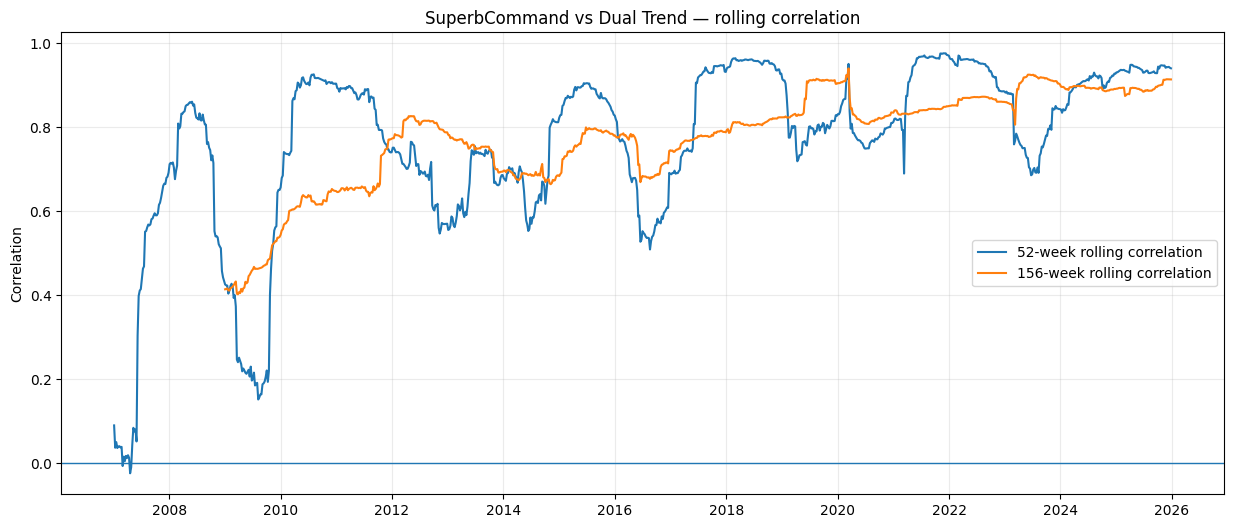

In [3]:
# ============================================================
# 8.3 — RETURN-STREAM RELATIONSHIP
# ============================================================
corr_full = legs.corr().iloc[0, 1]
opposite_sign_share = (
    np.sign(legs["SuperbCommand"]) != np.sign(legs["DualTrend"])
).mean()

relationship_summary = pd.DataFrame({
    "metric": [
        "full_sample_correlation",
        "opposite_weekly_sign_share",
    ],
    "value": [
        corr_full,
        opposite_sign_share,
    ],
})

display(relationship_summary)

rolling_corr_52 = legs["SuperbCommand"].rolling(52).corr(legs["DualTrend"])
rolling_corr_156 = legs["SuperbCommand"].rolling(156).corr(legs["DualTrend"])

plt.figure(figsize=(15, 6))
plt.plot(rolling_corr_52.index, rolling_corr_52.values, label="52-week rolling correlation")
plt.plot(rolling_corr_156.index, rolling_corr_156.values, label="156-week rolling correlation")
plt.axhline(0, linewidth=1)
plt.title("SuperbCommand vs Dual Trend — rolling correlation")
plt.ylabel("Correlation")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 8.4 Fixed coarse blends

The portfolio return for SuperbCommand weight \(\alpha\) is:

\[
R_t^{blend}
=
\alpha R_t^{SC}
+
(1-\alpha)R_t^{DT}
\]

with:

\[
\alpha \in \{1.00,0.75,0.50,0.25,0.00\}.
\]

These weights are deliberately coarse.


In [4]:
# ============================================================
# 8.4 — BUILD FIXED BLENDS
# ============================================================
SC_WEIGHTS = [1.00, 0.75, 0.50, 0.25, 0.00]

blend_returns = {}

for alpha in SC_WEIGHTS:
    name = f"SC_{int(alpha*100):03d}_DT_{int((1-alpha)*100):03d}"
    blend_returns[name] = (
        alpha * legs["SuperbCommand"]
        + (1 - alpha) * legs["DualTrend"]
    )

blend_panel = pd.DataFrame(blend_returns)

display(blend_panel.tail())


,SC_100_DT_000,SC_075_DT_025,SC_050_DT_050,SC_025_DT_075,SC_000_DT_100
date,,,,,
2025-11-28,0.008029,0.007753,0.007478,0.007203,0.006927
2025-12-05,-0.002038,-0.001729,-0.001420,-0.001112,-0.000803
2025-12-12,-0.001721,-0.001575,-0.001429,-0.001284,-0.001138
2025-12-19,0.001803,0.001880,0.001957,0.002034,0.002110
2025-12-26,0.004799,0.005128,0.005457,0.005786,0.006115


## 8.5 Performance metrics


In [5]:
# ============================================================
# 8.5 — PERFORMANCE FUNCTIONS
# ============================================================
WEEKS_PER_YEAR = 52

def max_drawdown(r):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    eq = (1 + r).cumprod()
    return float((eq / eq.cummax() - 1).min())

def cagr(r):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    wealth = float((1 + r).prod())
    years = len(r) / WEEKS_PER_YEAR
    if wealth <= 0 or years <= 0:
        return np.nan
    return wealth ** (1 / years) - 1

def ann_vol(r):
    r = pd.Series(r).dropna()
    if len(r) < 2:
        return np.nan
    return float(r.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR))

def sharpe(r):
    r = pd.Series(r).dropna()
    if len(r) < 2 or r.std(ddof=1) == 0:
        return np.nan
    return float(r.mean() / r.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR))

def sortino(r):
    r = pd.Series(r).dropna()
    downside = r[r < 0]
    if len(downside) < 2 or downside.std(ddof=1) == 0:
        return np.nan
    return float(r.mean() / downside.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR))

def calmar(r):
    ca = cagr(r)
    md = max_drawdown(r)
    if pd.isna(ca) or pd.isna(md) or md == 0:
        return np.nan
    return float(ca / abs(md))

def metrics(r):
    r = pd.Series(r).dropna()
    return {
        "weeks": len(r),
        "cagr": cagr(r),
        "ann_vol": ann_vol(r),
        "sharpe": sharpe(r),
        "sortino": sortino(r),
        "max_drawdown": max_drawdown(r),
        "calmar": calmar(r),
        "best_week": r.max() if len(r) else np.nan,
        "worst_week": r.min() if len(r) else np.nan,
        "positive_week_rate": (r > 0).mean() if len(r) else np.nan,
    }


In [6]:
# ============================================================
# 8.6 — FULL-SAMPLE BLEND PERFORMANCE
# ============================================================
rows = []

for name in blend_panel.columns:
    row = {"blend": name}
    row.update(metrics(blend_panel[name]))
    rows.append(row)

performance = pd.DataFrame(rows).sort_values("sharpe", ascending=False)

display(performance)


,blend,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,best_week,worst_week,positive_week_rate
3,SC_025_DT_075,1042,0.043936,0.031703,1.372703,1.904826,-0.042862,1.025068,0.025273,-0.028134,0.588292
4,SC_000_DT_100,1042,0.045561,0.033005,1.366982,1.891144,-0.041099,1.108570,0.024477,-0.027334,0.589251
2,SC_050_DT_050,1042,0.042277,0.031504,1.330633,1.852365,-0.050567,0.836061,0.026068,-0.028934,0.591171
1,SC_075_DT_025,1042,0.040582,0.032428,1.243406,1.711505,-0.058471,0.694061,0.026864,-0.029734,0.589251
0,SC_100_DT_000,1042,0.038854,0.034385,1.126137,1.538749,-0.066441,0.584784,0.027660,-0.030534,0.541267


## 8.7 Incremental value relative to pure Dual Trend

Because Dual Trend is currently the stronger standalone benchmark, the most important question is whether adding SuperbCommand improves it.

For each blend:

\[
\Delta Sharpe
=
Sharpe_{blend}
-
Sharpe_{DualTrend}
\]

and likewise for CAGR, Sortino, drawdown and Calmar.


In [7]:
# ============================================================
# 8.7 — DELTAS VS PURE DUAL TREND
# ============================================================
dt_name = "SC_000_DT_100"
dt_metrics = performance.set_index("blend").loc[dt_name]

delta_rows = []

for _, row in performance.iterrows():
    delta_rows.append({
        "blend": row["blend"],
        "delta_cagr_vs_dual_trend": row["cagr"] - dt_metrics["cagr"],
        "delta_sharpe_vs_dual_trend": row["sharpe"] - dt_metrics["sharpe"],
        "delta_sortino_vs_dual_trend": row["sortino"] - dt_metrics["sortino"],
        "delta_max_drawdown_vs_dual_trend": row["max_drawdown"] - dt_metrics["max_drawdown"],
        "delta_calmar_vs_dual_trend": row["calmar"] - dt_metrics["calmar"],
    })

deltas_vs_dual = pd.DataFrame(delta_rows).set_index("blend")

display(deltas_vs_dual)


,delta_cagr_vs_dual_trend,delta_sharpe_vs_dual_trend,delta_sortino_vs_dual_trend,delta_max_drawdown_vs_dual_trend,delta_calmar_vs_dual_trend
blend,,,,,
SC_025_DT_075,-0.001625,0.005721,0.013682,-0.001763,-0.083502
SC_000_DT_100,0.000000,0.000000,0.000000,0.000000,0.000000
SC_050_DT_050,-0.003285,-0.036349,-0.038778,-0.009467,-0.272509
SC_075_DT_025,-0.004979,-0.123576,-0.179638,-0.017372,-0.414508
SC_100_DT_000,-0.006708,-0.240845,-0.352395,-0.025342,-0.523786


## 8.8 Calendar-year consistency

A blend is more convincing if its improvement is not concentrated in one isolated year.


In [8]:
# ============================================================
# 8.8 — CALENDAR-YEAR RETURNS
# ============================================================
annual_rows = []

for name in blend_panel.columns:
    r = blend_panel[name].dropna()
    annual = (1 + r).groupby(r.index.year).prod() - 1

    for year, value in annual.items():
        annual_rows.append({
            "year": int(year),
            "blend": name,
            "return": value,
        })

annual_returns = pd.DataFrame(annual_rows)

annual_pivot = annual_returns.pivot(
    index="year",
    columns="blend",
    values="return",
)

display(annual_pivot.tail(15))


blend,SC_000_DT_100,SC_025_DT_075,SC_050_DT_050,SC_075_DT_025,SC_100_DT_000
year,,,,,
2011,0.033153,0.028024,0.022874,0.017702,0.012508
2012,-0.002482,-0.003867,-0.005273,-0.006702,-0.008152
2013,0.006092,0.005250,0.004379,0.003481,0.002555
2014,0.027357,0.025333,0.023302,0.021265,0.019220
2015,0.008969,0.006903,0.004817,0.002712,0.000587
2016,0.081159,0.073434,0.065710,0.057988,0.050270
2017,0.103131,0.100421,0.097710,0.094999,0.092286
2018,-0.000355,-0.003042,-0.005730,-0.008417,-0.011105
2019,0.082412,0.085743,0.089068,0.092389,0.095703


## 8.9 Annual superiority versus Dual Trend

For each blend, count how often it beats pure Dual Trend on calendar-year return.

This is descriptive only; the blend weight is not chosen from this table.


In [9]:
# ============================================================
# 8.9 — YEARLY OUTPERFORMANCE FREQUENCY
# ============================================================
dual_annual = annual_pivot["SC_000_DT_100"]

outperf_rows = []

for name in blend_panel.columns:
    common = pd.concat(
        [annual_pivot[name].rename("blend"), dual_annual.rename("dual")],
        axis=1
    ).dropna()

    outperf_rows.append({
        "blend": name,
        "years": len(common),
        "years_beating_dual_trend": int((common["blend"] > common["dual"]).sum()),
        "share_years_beating_dual_trend": (common["blend"] > common["dual"]).mean(),
        "mean_annual_excess_return": (common["blend"] - common["dual"]).mean(),
        "median_annual_excess_return": (common["blend"] - common["dual"]).median(),
    })

annual_outperformance = pd.DataFrame(outperf_rows).set_index("blend")
display(annual_outperformance)


,years,years_beating_dual_trend,share_years_beating_dual_trend,mean_annual_excess_return,median_annual_excess_return
blend,,,,,
SC_100_DT_000,20,9,0.45,-0.006444,-0.004603
SC_075_DT_025,20,9,0.45,-0.004844,-0.003415
SC_050_DT_050,20,9,0.45,-0.003236,-0.002252
SC_025_DT_075,20,9,0.45,-0.001622,-0.001114
SC_000_DT_100,20,0,0.00,0.000000,0.000000


## 8.10 Rolling Sharpe comparison

Five-year rolling Sharpe helps determine whether the blend's advantage is persistent or regime-specific.


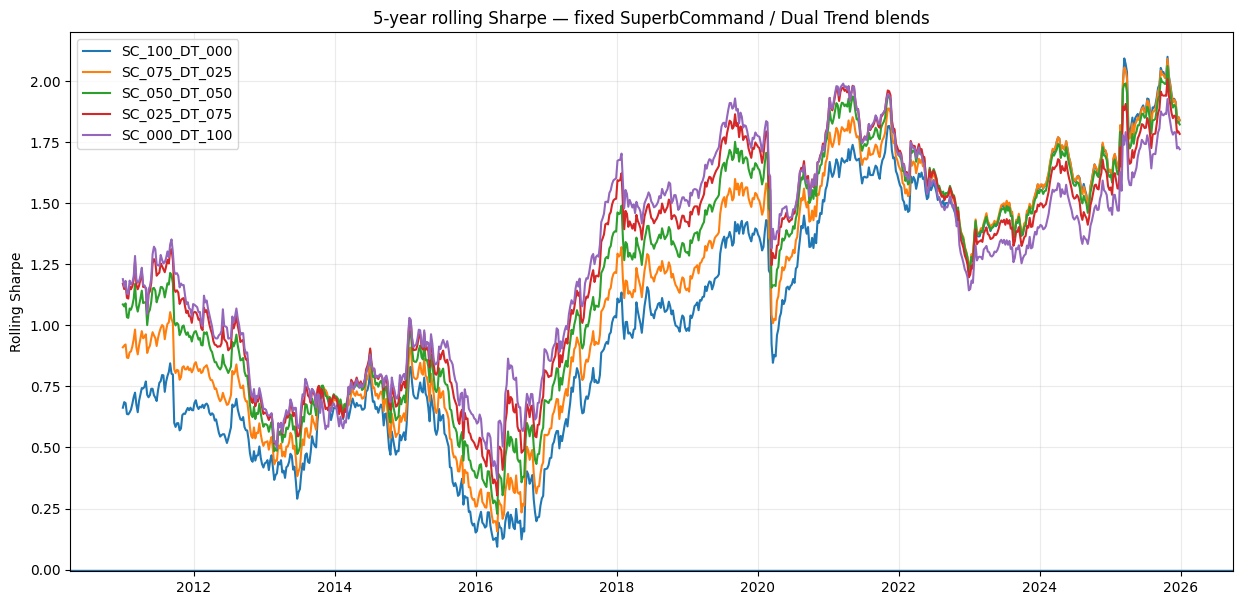

In [10]:
# ============================================================
# 8.10 — 5-YEAR ROLLING SHARPE
# ============================================================
ROLL_WEEKS = 5 * 52

def rolling_sharpe(r, window=ROLL_WEEKS):
    mean = r.rolling(window, min_periods=window).mean()
    vol = r.rolling(window, min_periods=window).std(ddof=1)
    return mean / vol.replace(0, np.nan) * np.sqrt(WEEKS_PER_YEAR)

plt.figure(figsize=(15, 7))

for name in blend_panel.columns:
    rs = rolling_sharpe(blend_panel[name])
    plt.plot(rs.index, rs.values, label=name)

plt.axhline(0, linewidth=1)
plt.title("5-year rolling Sharpe — fixed SuperbCommand / Dual Trend blends")
plt.ylabel("Rolling Sharpe")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 8.11 Equity curves


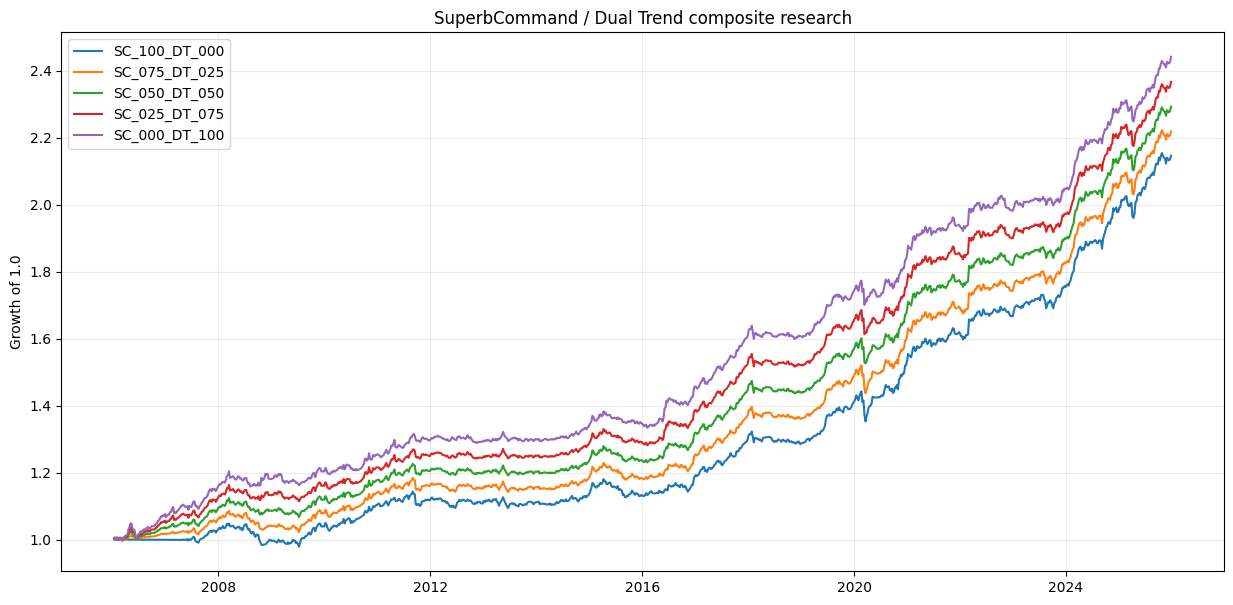

In [11]:
# ============================================================
# 8.11 — EQUITY CURVES
# ============================================================
plt.figure(figsize=(15, 7))

for name in blend_panel.columns:
    eq = (1 + blend_panel[name].fillna(0)).cumprod()
    plt.plot(eq.index, eq.values, label=name)

plt.title("SuperbCommand / Dual Trend composite research")
plt.ylabel("Growth of 1.0")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 8.12 Drawdowns


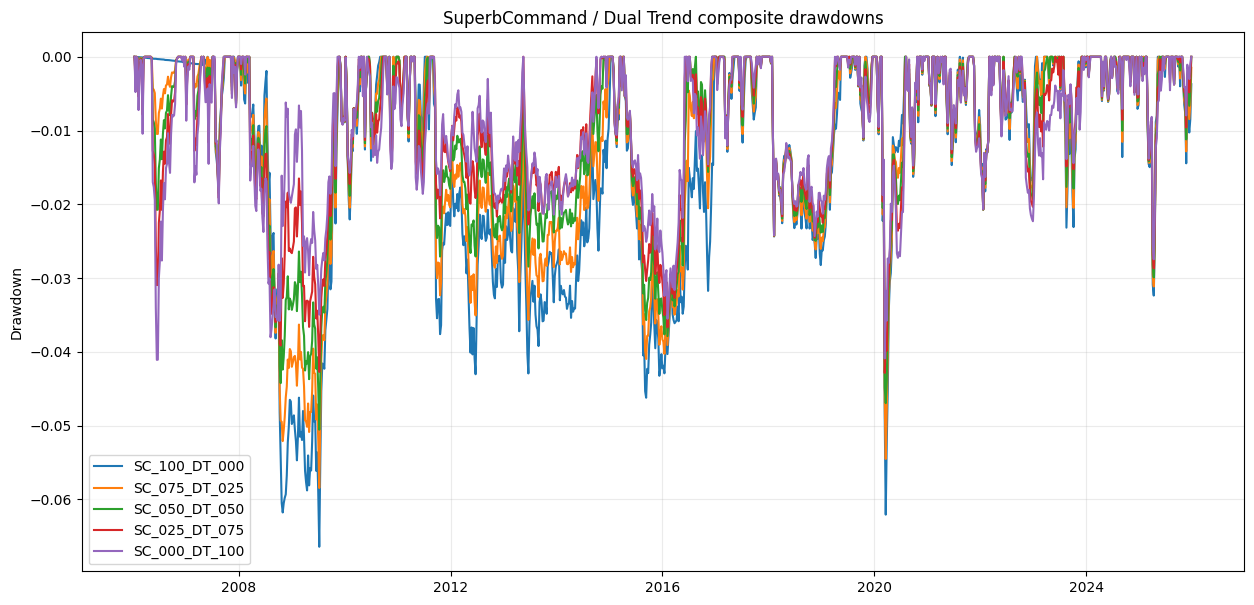

In [12]:
# ============================================================
# 8.12 — DRAWDOWN COMPARISON
# ============================================================
plt.figure(figsize=(15, 7))

for name in blend_panel.columns:
    eq = (1 + blend_panel[name].fillna(0)).cumprod()
    dd = eq / eq.cummax() - 1
    plt.plot(dd.index, dd.values, label=name)

plt.title("SuperbCommand / Dual Trend composite drawdowns")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 8.13 Stress-period comparison

These are the same pre-specified historical stress periods used throughout the project.

The key question is whether SuperbCommand improves the conventional trend model in the specific environments where Notebook 06–07 suggested different behaviour.


In [13]:
# ============================================================
# 8.13 — STRESS PERIODS
# ============================================================
STRESS_PERIODS = {
    "Global Financial Crisis": ("2007-07-01", "2009-03-31"),
    "Euro-area stress": ("2011-05-01", "2012-07-31"),
    "COVID crash": ("2020-02-01", "2020-04-30"),
    "2022 inflation/rates shock": ("2022-01-01", "2022-12-31"),
}

stress_rows = []

for period, (start, end) in STRESS_PERIODS.items():
    for name in blend_panel.columns:
        r = blend_panel[name].loc[start:end].dropna()

        if len(r) == 0:
            continue

        stress_rows.append({
            "period": period,
            "blend": name,
            "weeks": len(r),
            "total_return": (1 + r).prod() - 1,
            "max_drawdown": max_drawdown(r),
            "worst_week": r.min(),
        })

stress = pd.DataFrame(stress_rows)

display(stress)


,period,blend,weeks,total_return,max_drawdown,worst_week
0,Global Financial Crisis,SC_100_DT_000,91,-0.006475,-0.061787,-0.015752
1,Global Financial Crisis,SC_075_DT_025,91,0.012459,-0.052112,-0.013777
2,Global Financial Crisis,SC_050_DT_050,91,0.031599,-0.044249,-0.012548
3,Global Financial Crisis,SC_025_DT_075,91,0.050945,-0.039163,-0.014664
4,Global Financial Crisis,SC_000_DT_100,91,0.070493,-0.038025,-0.016781
5,Euro-area stress,SC_100_DT_000,65,-0.008064,-0.043045,-0.026096
6,Euro-area stress,SC_075_DT_025,65,-0.004773,-0.035076,-0.022040
7,Euro-area stress,SC_050_DT_050,65,-0.001529,-0.027089,-0.017984
8,Euro-area stress,SC_025_DT_075,65,0.001666,-0.021915,-0.014225
9,Euro-area stress,SC_000_DT_100,65,0.004813,-0.018759,-0.016361


## 8.14 Return contribution decomposition

For each composite, decompose average weekly return contribution from:

- SuperbCommand leg;
- Dual Trend leg.

This makes it easier to see whether the blend merely dilutes Dual Trend or whether SuperbCommand contributes meaningful positive return.


In [14]:
# ============================================================
# 8.14 — CONTRIBUTION DECOMPOSITION
# ============================================================
contrib_rows = []

for alpha in SC_WEIGHTS:
    name = f"SC_{int(alpha*100):03d}_DT_{int((1-alpha)*100):03d}"

    sc_contrib = alpha * legs["SuperbCommand"]
    dt_contrib = (1 - alpha) * legs["DualTrend"]

    contrib_rows.append({
        "blend": name,
        "sc_weight": alpha,
        "dual_weight": 1 - alpha,
        "annualised_sc_return_contribution_approx": sc_contrib.mean() * WEEKS_PER_YEAR,
        "annualised_dual_return_contribution_approx": dt_contrib.mean() * WEEKS_PER_YEAR,
        "annualised_total_mean_return_approx": (
            sc_contrib.mean() + dt_contrib.mean()
        ) * WEEKS_PER_YEAR,
    })

contribution_summary = pd.DataFrame(contrib_rows).set_index("blend")

display(contribution_summary)


,sc_weight,dual_weight,annualised_sc_return_contribution_approx,annualised_dual_return_contribution_approx,annualised_total_mean_return_approx
blend,,,,,
SC_100_DT_000,1.00,0.00,0.038723,0.000000,0.038723
SC_075_DT_025,0.75,0.25,0.029042,0.011279,0.040321
SC_050_DT_050,0.50,0.50,0.019361,0.022559,0.041920
SC_025_DT_075,0.25,0.75,0.009681,0.033838,0.043518
SC_000_DT_100,0.00,1.00,0.000000,0.045117,0.045117


## 8.15 Coarse walk-forward blend test

To avoid choosing a blend solely from the full sample, Notebook 08 also performs a deliberately simple walk-forward selection among the **five pre-specified blend weights**.

The selector uses:

\[
5\text{-year train} \rightarrow 1\text{-year test}
\]

and ranks blend weights by training Sharpe only.

This does **not** alter the underlying SuperbCommand or Dual Trend parameters.


In [15]:
# ============================================================
# 8.15 — 5Y / 1Y WALK-FORWARD BLEND SELECTION
# ============================================================
FIRST_TEST_YEAR = 2011
LAST_TEST_YEAR = 2025
TRAIN_YEARS = 5

wf_rows = []
wf_returns = []

for test_year in range(FIRST_TEST_YEAR, LAST_TEST_YEAR + 1):
    train_start = test_year - TRAIN_YEARS
    train_end = test_year - 1

    train = blend_panel[
        (blend_panel.index.year >= train_start)
        & (blend_panel.index.year <= train_end)
    ]

    test = blend_panel[
        blend_panel.index.year == test_year
    ]

    rankings = []

    for name in blend_panel.columns:
        m = metrics(train[name])
        rankings.append({
            "blend": name,
            "train_sharpe": m["sharpe"],
            "train_calmar": m["calmar"],
        })

    rank_df = pd.DataFrame(rankings)
    rank_df["sharpe_rank"] = rank_df["train_sharpe"].fillna(-np.inf)
    rank_df["calmar_rank"] = rank_df["train_calmar"].fillna(-np.inf)

    rank_df = rank_df.sort_values(
        ["sharpe_rank", "calmar_rank", "blend"],
        ascending=[False, False, True],
    )

    selected = rank_df.iloc[0]["blend"]
    test_r = test[selected].dropna()

    if len(test_r):
        wf_returns.append(test_r)

    tm = metrics(test_r)

    wf_rows.append({
        "test_year": test_year,
        "train_start_year": train_start,
        "train_end_year": train_end,
        "selected_blend": selected,
        "selected_train_sharpe": rank_df.iloc[0]["train_sharpe"],
        "test_weeks": tm["weeks"],
        "test_cagr": tm["cagr"],
        "test_sharpe": tm["sharpe"],
        "test_max_drawdown": tm["max_drawdown"],
    })

wf_selection = pd.DataFrame(wf_rows)

wf_blend_return = pd.concat(wf_returns).sort_index()
wf_blend_metrics = pd.DataFrame(
    [{"strategy": "WF_BLEND_SELECTOR", **metrics(wf_blend_return)}]
).set_index("strategy")

display(wf_selection)
display(wf_blend_metrics)


,test_year,train_start_year,train_end_year,selected_blend,selected_train_sharpe,test_weeks,test_cagr,test_sharpe,test_max_drawdown
0,2011,2006,2010,SC_000_DT_100,1.189047,52,0.033153,1.009452,-0.018759
1,2012,2007,2011,SC_000_DT_100,1.030457,52,-0.002482,-0.127481,-0.017698
2,2013,2008,2012,SC_000_DT_100,0.687751,52,0.006092,0.301400,-0.021407
3,2014,2009,2013,SC_025_DT_075,0.711114,52,0.025333,1.453625,-0.007320
4,2015,2010,2014,SC_000_DT_100,0.796507,52,0.008969,0.343846,-0.026469
5,2016,2011,2015,SC_000_DT_100,0.618948,53,0.079569,2.027498,-0.014594
6,2017,2012,2016,SC_000_DT_100,0.928427,52,0.103131,3.755630,-0.012046
7,2018,2013,2017,SC_000_DT_100,1.617009,52,-0.000355,0.001189,-0.024310
8,2019,2014,2018,SC_000_DT_100,1.499355,52,0.082412,3.421012,-0.010932
9,2020,2015,2019,SC_000_DT_100,1.806888,52,0.056102,1.096469,-0.040895


,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,best_week,worst_week,positive_week_rate
strategy,,,,,,,,,,
WF_BLEND_SELECTOR,782,0.047762,0.03183,1.482315,2.135838,-0.040895,1.167906,0.025273,-0.027334,0.584399


## 8.16 Walk-forward blend selection stability

If the preferred blend weight flips constantly, we should not promote a dynamic blending layer.


In [16]:
# ============================================================
# 8.16 — BLEND SELECTION STABILITY
# ============================================================
blend_selection_frequency = (
    wf_selection["selected_blend"]
    .value_counts()
    .rename("years_selected")
    .to_frame()
)

choices = wf_selection["selected_blend"].tolist()
switches = sum(a != b for a, b in zip(choices[:-1], choices[1:]))

blend_switch_summary = pd.DataFrame([{
    "test_years": len(choices),
    "switches": switches,
    "switch_rate": switches / max(len(choices) - 1, 1),
    "unique_blends_selected": len(set(choices)),
}])

display(blend_selection_frequency)
display(blend_switch_summary)


,years_selected
selected_blend,
SC_000_DT_100,9
SC_025_DT_075,3
SC_075_DT_025,3


,test_years,switches,switch_rate,unique_blends_selected
0,15,4,0.285714,3


## 8.17 Compare dynamic blend selector with fixed blends

The dynamic selector only adds value if it materially improves upon the best fixed coarse blend without creating excessive instability.


In [17]:
# ============================================================
# 8.17 — DYNAMIC VS FIXED BLENDS ON COMMON OOS PERIOD
# ============================================================
oos_start = wf_blend_return.index.min()
oos_end = wf_blend_return.index.max()

oos_rows = [{
    "strategy": "WF_BLEND_SELECTOR",
    **metrics(wf_blend_return),
}]

for name in blend_panel.columns:
    r = blend_panel[name].loc[oos_start:oos_end].dropna()
    oos_rows.append({
        "strategy": name,
        **metrics(r),
    })

oos_comparison = pd.DataFrame(oos_rows).sort_values(
    "sharpe", ascending=False
)

display(oos_comparison)


,strategy,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,best_week,worst_week,positive_week_rate
0,WF_BLEND_SELECTOR,782,0.047762,0.031830,1.482315,2.135838,-0.040895,1.167906,0.025273,-0.027334,0.584399
5,SC_000_DT_100,782,0.045304,0.030892,1.450324,2.092592,-0.040895,1.107815,0.024477,-0.027334,0.579284
4,SC_025_DT_075,782,0.045327,0.030984,1.446800,2.056666,-0.042862,1.057500,0.025273,-0.028134,0.580563
3,SC_050_DT_050,782,0.045324,0.031843,1.408537,1.985486,-0.046960,0.965168,0.026068,-0.028934,0.584399
2,SC_075_DT_025,782,0.045296,0.033410,1.343213,1.884180,-0.054535,0.830592,0.026864,-0.029734,0.583120
1,SC_100_DT_000,782,0.045243,0.035591,1.261579,1.755133,-0.062084,0.728737,0.027660,-0.030534,0.571611


## 8.18 Research interpretation flags

Notebook 08 does not automatically declare a winning blend.

Instead, it records whether any **non-zero SuperbCommand allocation** improves the pure Dual Trend benchmark.

A positive result is stronger if it appears in:

- full-sample Sharpe;
- Sortino;
- Calmar;
- drawdown;
- multiple stress periods;
- walk-forward comparison.

If only one statistic improves, the evidence should be treated as weak.


In [18]:
# ============================================================
# 8.18 — STRUCTURAL EVIDENCE SUMMARY
# ============================================================
perf_idx = performance.set_index("blend")
pure_dual = perf_idx.loc["SC_000_DT_100"]

evidence_rows = []

for name, row in perf_idx.iterrows():
    sc_weight = int(name.split("_")[1]) / 100

    if sc_weight == 0:
        continue

    evidence_rows.append({
        "blend": name,
        "sc_weight": sc_weight,
        "sharpe_improves_vs_dual": row["sharpe"] > pure_dual["sharpe"],
        "sortino_improves_vs_dual": row["sortino"] > pure_dual["sortino"],
        "calmar_improves_vs_dual": row["calmar"] > pure_dual["calmar"],
        "max_drawdown_improves_vs_dual": row["max_drawdown"] > pure_dual["max_drawdown"],
        "cagr_improves_vs_dual": row["cagr"] > pure_dual["cagr"],
    })

evidence_summary = pd.DataFrame(evidence_rows)

evidence_summary["count_metrics_improved"] = evidence_summary[
    [
        "sharpe_improves_vs_dual",
        "sortino_improves_vs_dual",
        "calmar_improves_vs_dual",
        "max_drawdown_improves_vs_dual",
        "cagr_improves_vs_dual",
    ]
].sum(axis=1)

display(evidence_summary.sort_values(
    "count_metrics_improved",
    ascending=False,
))


,blend,sc_weight,sharpe_improves_vs_dual,sortino_improves_vs_dual,calmar_improves_vs_dual,max_drawdown_improves_vs_dual,cagr_improves_vs_dual,count_metrics_improved
0,SC_025_DT_075,0.25,True,True,False,False,False,2
1,SC_050_DT_050,0.50,False,False,False,False,False,0
2,SC_075_DT_025,0.75,False,False,False,False,False,0
3,SC_100_DT_000,1.00,False,False,False,False,False,0


## 8.19 Save outputs


In [19]:
# ============================================================
# 8.19 — SAVE OUTPUTS
# ============================================================
RELATIONSHIP_PATH = PATHS["results"] / "08_sc_dualtrend_relationship.csv"
PERF_PATH = PATHS["results"] / "08_composite_performance.csv"
DELTA_PATH = PATHS["results"] / "08_composite_deltas_vs_dualtrend.csv"
ANNUAL_PATH = PATHS["results"] / "08_composite_annual_returns.csv"
OUTPERF_PATH = PATHS["results"] / "08_composite_annual_outperformance.csv"
STRESS_PATH = PATHS["results"] / "08_composite_stress_summary.csv"
CONTRIB_PATH = PATHS["results"] / "08_composite_contribution_summary.csv"
WF_SELECTION_PATH = PATHS["results"] / "08_composite_walkforward_selection.csv"
WF_COMPARE_PATH = PATHS["results"] / "08_composite_walkforward_comparison.csv"
EVIDENCE_PATH = PATHS["results"] / "08_composite_evidence_summary.csv"

BLEND_RETURNS_PATH = PATHS["data_processed"] / "08_composite_return_panel.parquet"
WF_BLEND_RETURNS_PATH = PATHS["data_processed"] / "08_composite_walkforward_return.parquet"

relationship_summary.to_csv(RELATIONSHIP_PATH, index=False)
performance.to_csv(PERF_PATH, index=False)
deltas_vs_dual.to_csv(DELTA_PATH)
annual_returns.to_csv(ANNUAL_PATH, index=False)
annual_outperformance.to_csv(OUTPERF_PATH)
stress.to_csv(STRESS_PATH, index=False)
contribution_summary.to_csv(CONTRIB_PATH)
wf_selection.to_csv(WF_SELECTION_PATH, index=False)
oos_comparison.to_csv(WF_COMPARE_PATH, index=False)
evidence_summary.to_csv(EVIDENCE_PATH, index=False)

blend_panel.to_parquet(BLEND_RETURNS_PATH)
wf_blend_return.to_frame("WF_BLEND_SELECTOR").to_parquet(WF_BLEND_RETURNS_PATH)

print("Saved Notebook 08 outputs.")


Saved Notebook 08 outputs.


## 8.20 Validation suite

Notebook 08 passes only if:

- 2026 remains absent;
- exactly five pre-specified blend weights are tested;
- pure SuperbCommand and pure Dual Trend are both present;
- all composite returns are exact linear combinations of the two fixed legs;
- walk-forward blend selection uses only prior five-year training data;
- all outputs are written.


In [20]:
# ============================================================
# 8.20 — VALIDATION SUITE
# ============================================================
checks = {}

checks["holdout_absent"] = blend_panel.index.max() <= RESEARCH_END
checks["2026_absent"] = not (blend_panel.index.year == 2026).any()

checks["five_fixed_blends_present"] = len(blend_panel.columns) == 5

checks["pure_sc_present"] = "SC_100_DT_000" in blend_panel.columns
checks["pure_dual_present"] = "SC_000_DT_100" in blend_panel.columns

linear_combo_ok = True

for alpha in SC_WEIGHTS:
    name = f"SC_{int(alpha*100):03d}_DT_{int((1-alpha)*100):03d}"
    expected = (
        alpha * legs["SuperbCommand"]
        + (1-alpha) * legs["DualTrend"]
    )

    if not np.allclose(
        blend_panel[name].to_numpy(),
        expected.to_numpy(),
        equal_nan=True,
    ):
        linear_combo_ok = False
        break

checks["all_blends_exact_linear_combinations"] = linear_combo_ok

checks["wf_train_precedes_test"] = (
    wf_selection["train_end_year"]
    < wf_selection["test_year"]
).all()

checks["wf_training_exactly_5y"] = (
    wf_selection["train_end_year"]
    - wf_selection["train_start_year"]
    + 1
).eq(5).all()

checks["wf_2026_absent"] = not (wf_blend_return.index.year == 2026).any()

checks["output_files_written"] = all(
    p.exists()
    for p in [
        RELATIONSHIP_PATH,
        PERF_PATH,
        DELTA_PATH,
        ANNUAL_PATH,
        OUTPERF_PATH,
        STRESS_PATH,
        CONTRIB_PATH,
        WF_SELECTION_PATH,
        WF_COMPARE_PATH,
        EVIDENCE_PATH,
        BLEND_RETURNS_PATH,
        WF_BLEND_RETURNS_PATH,
    ]
)

validation = pd.DataFrame({
    "check": list(checks.keys()),
    "passed": list(checks.values()),
})

print(validation.to_string(index=False))

if not all(checks.values()):
    failed = [k for k, v in checks.items() if not v]
    raise RuntimeError(f"Notebook 08 validation failed: {failed}")

print("\n" + "=" * 78)
print("NOTEBOOK 08 STATUS: PASS")
print("=" * 78)
print("SuperbCommand / Dual Trend composite research completed.")
print("Only five coarse blend weights were tested.")
print("No underlying signal hyperparameters were optimised.")
print("2026 final holdout: NOT ACCESSED")
print("Review the structural evidence before the next notebook.")


                               check  passed
                      holdout_absent    True
                         2026_absent    True
           five_fixed_blends_present    True
                     pure_sc_present    True
                   pure_dual_present    True
all_blends_exact_linear_combinations    True
              wf_train_precedes_test    True
              wf_training_exactly_5y    True
                      wf_2026_absent    True
                output_files_written    True

NOTEBOOK 08 STATUS: PASS
SuperbCommand / Dual Trend composite research completed.
Only five coarse blend weights were tested.
No underlying signal hyperparameters were optimised.
2026 final holdout: NOT ACCESSED
Review the structural evidence before the next notebook.


In [21]:
# ============================================================
# 8.21 — WRITE MANIFEST
# ============================================================
manifest = {
    "notebook_id": "08",
    "notebook_name": "SuperbCommand + Dual-Trend Composite Research",
    "project_name": "SuperbCommand – Multi-Asset CTA Strategy",
    "run_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "research_end": str(RESEARCH_END.date()),
    "holdout_start": str(HOLDOUT_START.date()),
    "holdout_accessed": False,
    "superbcommand_leg": {
        "variant": "PT_REDUCE_25",
        "portfolio_method": "hier_inverse_vol",
    },
    "dual_trend_leg": {
        "signal": "DUAL_TREND_13_52",
        "portfolio_method": "hier_inverse_vol",
    },
    "fixed_superbcommand_weights": SC_WEIGHTS,
    "walk_forward_blend_selection": {
        "training_years": 5,
        "test_years": 1,
        "selection_metric": "Sharpe ratio",
        "tie_breaker": "Calmar ratio",
    },
    "signal_hyperparameters_optimised": False,
    "outputs": {
        "relationship_summary": str(RELATIONSHIP_PATH),
        "performance": str(PERF_PATH),
        "deltas_vs_dualtrend": str(DELTA_PATH),
        "annual_returns": str(ANNUAL_PATH),
        "annual_outperformance": str(OUTPERF_PATH),
        "stress_summary": str(STRESS_PATH),
        "contribution_summary": str(CONTRIB_PATH),
        "walkforward_selection": str(WF_SELECTION_PATH),
        "walkforward_comparison": str(WF_COMPARE_PATH),
        "evidence_summary": str(EVIDENCE_PATH),
        "composite_return_panel": str(BLEND_RETURNS_PATH),
        "walkforward_return": str(WF_BLEND_RETURNS_PATH),
    },
    "status": "PASS",
}

MANIFEST_PATH = PATHS["manifests"] / "08_sc_dualtrend_composite_manifest.json"

with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("Saved manifest:")
print(MANIFEST_PATH)


Saved manifest:
/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/manifests/08_sc_dualtrend_composite_manifest.json


---

# End of Notebook 08

## Main question

\[
\boxed{\text{Does SuperbCommand improve conventional Dual Trend when the two are blended?}}
\]

The notebook deliberately tests only five coarse fixed blends plus a simple 5-year/1-year walk-forward blend selector.

### Interpretation rule

A non-zero SuperbCommand allocation should only be promoted if it improves the evidence **across several dimensions**, not merely one full-sample statistic.

### Final holdout

**2026 remains completely untouched.**

Do not unlock it until the research architecture has been frozen.
